# Q4 — Cross-task Functional (NTK) Coupling in HiP-AD (aux ↔ plan)

**핵심 주장**: aux task(det/map/motion)와 planning은 공유 표현(inter_gnn)에서 *scene별로* 함수적으로 결합돼 있으나, **loss-gradient는 그걸 못 본다**(부호 상쇄 + 일반 부분공간만 감지).

쪼개짐: `g = Jᵀ r` (gradient = 구조 J × 오차 r).  ⟨g_aux, g_plan⟩ = r_auxᵀ **K** r_plan,  K = J_aux J_planᵀ (cross-task 커널).
상쇄은 오차 r 때문.  Q4는 r 대신 랜덤 방향 u,v로 K를 직접 측정: `cos(J_planᵀ u, J_auxᵀ v)`.

| 양 | 의미 |
|---|---|
| `cosfunc_same` | 같은 scene cross-task 함수 정렬 (≈ ‖K‖, 상쇄-불변) |
| `cosshuf` | 다른 scene끼리 (공유 부분공간 baseline = null) |
| `|cos_loss|` | loss-gradient가 실제로 본 것 (상쇄되는 그것) |
| `floor` | 랜덤 param 벡터 cosine (차원 바닥 ~0) |

In [1]:
%matplotlib inline
import glob, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from scipy.stats import wilcoxon
except Exception:
    wilcoxon = None

RES = '/home/yongjae/e2e/HiP-AD-pcgrad/gradient_analysis_results'
files = [f for f in sorted(glob.glob(os.path.join(RES, 'ntk_*.csv'))) if 'smoke' not in f]
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
AUX = ['det', 'map', 'motion']
ORDER = {'1ep': 1, '3ep': 3, '9ep': 9, '18ep': 18}
CKPTS = sorted(df.ckpt.unique(), key=lambda c: ORDER.get(c, 99))
COL = {'same': '#d62728', 'shuf': '#1f77b4', 'loss': '#7f7f7f', 'floor': '#cccccc'}
print(f'{len(df)} samples | ckpts={CKPTS} | files={[os.path.basename(f) for f in files]}')
df.head(3)

2150 samples | ckpts=['1ep', '3ep', '9ep', '18ep'] | files=['ntk_18ep.csv', 'ntk_1ep.csv', 'ntk_3ep.csv', 'ntk_9ep.csv', 'ntk_ft_baseline.csv', 'ntk_ft_coupling_l1.csv', 'ntk_ft_coupling_l5.csv']


,cos_loss_det,cosfunc_absmean_det,cosfunc_mean_det,cos_loss_map,cosfunc_absmean_map,cosfunc_mean_map,cos_loss_motion,cosfunc_absmean_motion,cosfunc_mean_motion,cos_paramfloor,...,n_bound,ctrl_lidarpts,ctrl_random,n_relevant,min_dist_path,token,cosshuf_absmean_det,cosshuf_absmean_map,cosshuf_absmean_motion,ckpt
0,0.031434,0.057732,-0.048852,0.038074,0.092500,0.016694,-0.002590,0.031163,-0.008172,0.001160,...,2,557,0.857946,0,7.346500,1.537299e+09,NaN,NaN,NaN,18ep
1,0.009150,0.103739,0.056924,-0.002529,0.070381,0.010130,0.008011,0.034174,0.005452,0.001126,...,3,3498,0.857946,5,3.401535,1.535385e+09,0.027072,0.032860,0.016497,18ep
2,-0.019850,0.032428,0.018202,-0.013093,0.060994,0.007090,-0.011915,0.033283,-0.016568,0.000728,...,2,403,0.857946,0,12.899674,1.538985e+09,0.020387,0.035544,0.013279,18ep


## 요약 표 — per (ckpt, aux): same / shuf / |loss| / ratio / paired diff / Wilcoxon p

In [2]:
def boot_ci(d, n=4000, seed=1):
    d = np.asarray(d, float); d = d[np.isfinite(d)]
    if len(d) < 10: return (np.nan, np.nan, np.nan)
    rng = np.random.RandomState(seed)
    m = [d[rng.randint(0, len(d), len(d))].mean() for _ in range(n)]
    return d.mean(), np.percentile(m, 2.5), np.percentile(m, 97.5)

rows = []
for ck in CKPTS:
    d = df[df.ckpt == ck]
    for aux in AUX:
        same = d[f'cosfunc_absmean_{aux}']
        shuf = d[f'cosshuf_absmean_{aux}']
        loss = d[f'cos_loss_{aux}'].abs()
        pr = pd.concat([same, shuf], axis=1).dropna()
        dd = (pr.iloc[:, 0] - pr.iloc[:, 1]).values
        m, lo, hi = boot_ci(dd)
        try:
            p = wilcoxon(dd, alternative='greater').pvalue if (wilcoxon and len(dd) > 10) else np.nan
        except Exception:
            p = np.nan
        rows.append(dict(ckpt=ck, aux=aux, n=len(d), same=same.mean(), shuf=shuf.mean(),
                         loss=loss.mean(), floor=d.cos_paramfloor.abs().mean(),
                         ratio=same.mean()/shuf.mean(), diff=m, ci_lo=lo, ci_hi=hi, wilcoxon_p=p))
S = pd.DataFrame(rows)
S.round(4)

,ckpt,aux,n,same,shuf,loss,floor,ratio,diff,ci_lo,ci_hi,wilcoxon_p
0,1ep,det,400,0.0732,0.0317,0.0222,0.0009,2.3099,0.0416,0.0384,0.0451,0.0
1,1ep,map,400,0.0957,0.0370,0.0324,0.0009,2.5870,0.0587,0.0544,0.0632,0.0
2,1ep,motion,400,0.0630,0.0277,0.0238,0.0009,2.2737,0.0353,0.0320,0.0388,0.0
3,3ep,det,400,0.0760,0.0294,0.0248,0.0009,2.5836,0.0467,0.0433,0.0502,0.0
4,3ep,map,400,0.1042,0.0369,0.0355,0.0009,2.8225,0.0671,0.0627,0.0717,0.0
5,3ep,motion,400,0.0614,0.0253,0.0316,0.0009,2.4224,0.0360,0.0330,0.0390,0.0
6,9ep,det,950,0.0790,0.0273,0.0204,0.0009,2.8971,0.0516,0.0490,0.0543,0.0
7,9ep,map,950,0.1020,0.0340,0.0292,0.0009,3.0033,0.0680,0.0644,0.0718,0.0
8,9ep,motion,950,0.0567,0.0238,0.0235,0.0009,2.3835,0.0330,0.0309,0.0353,0.0
9,18ep,det,400,0.0596,0.0258,0.0225,0.0009,2.3072,0.0337,0.0312,0.0364,0.0


## Fig 1 — 헤드라인: 체크포인트별 same vs shuf vs |loss| vs floor
`same`(빨강) 막대가 `shuf`·`|loss|`의 ~2.5배, `floor`는 거의 0.

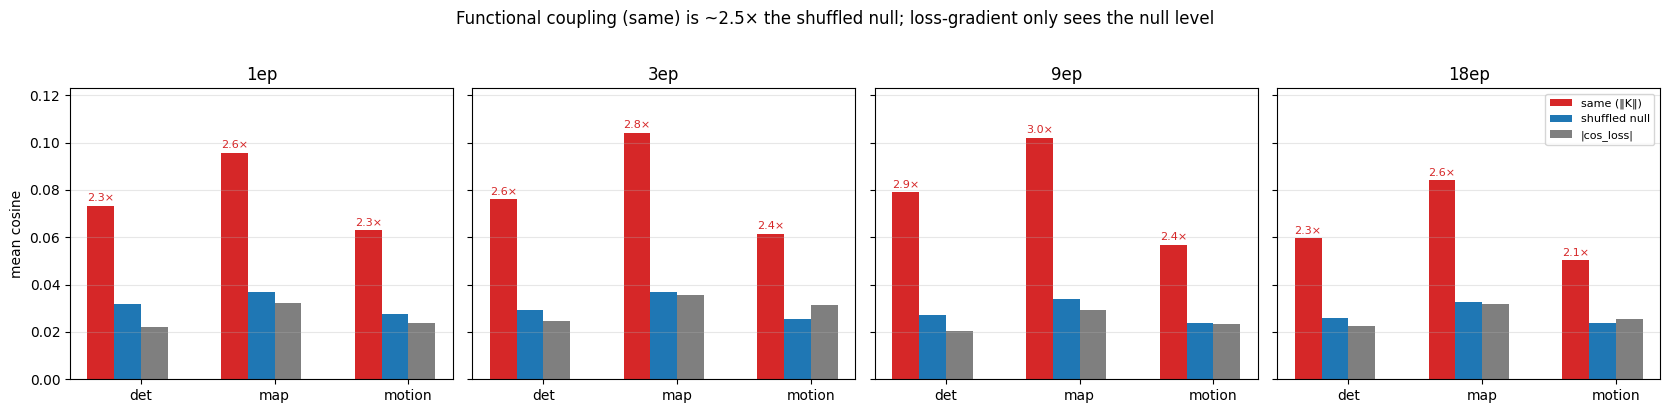

In [9]:
fig, axes = plt.subplots(1, len(CKPTS), figsize=(4.2 * len(CKPTS), 4), sharey=True)
x = np.arange(len(AUX)); w = 0.2
for ax, ck in zip(np.atleast_1d(axes), CKPTS):
    s = S[S.ckpt == ck].set_index('aux').loc[AUX]
    ax.bar(x - 1.5*w, s['same'],  w, label='same (‖K‖)', color=COL['same'])
    ax.bar(x - 0.5*w, s['shuf'],  w, label='shuffled null', color=COL['shuf'])
    ax.bar(x + 0.5*w, s['loss'],  w, label='|cos_loss|', color=COL['loss'])
    for xi, aux in zip(x, AUX):
        ax.text(xi - 1.5*w, s.loc[aux, 'same'] + 0.002, f"{s.loc[aux,'ratio']:.1f}×",
                ha='center', fontsize=8, color=COL['same'])
    ax.set_xticks(x); ax.set_xticklabels(AUX); ax.set_title(ck)
    ax.set_ylim(0, max(0.11, S['same'].max()*1.18)); ax.grid(axis='y', alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel('mean cosine')
np.atleast_1d(axes)[-1].legend(fontsize=8, loc='upper right')
fig.suptitle('Functional coupling (same) is ~2.5× the shuffled null; loss-gradient only sees the null level', y=1.02)
plt.tight_layout(); plt.show()

## Fig 2 — ratio (same / shuf) 체크포인트 추세
1.0 = 결합 없음.  모든 epoch·task에서 2.1~2.8×로 안정.

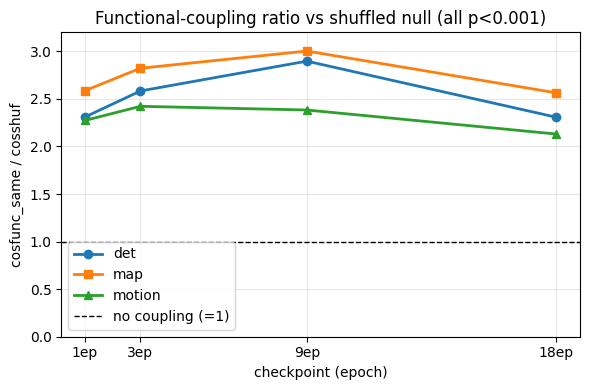

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
xs = [ORDER[c] for c in CKPTS]
for aux, mk in zip(AUX, ['o', 's', '^']):
    ys = [S[(S.ckpt == c) & (S.aux == aux)]['ratio'].iloc[0] for c in CKPTS]
    ax.plot(xs, ys, marker=mk, label=aux, lw=2)
ax.axhline(1.0, color='k', ls='--', lw=1, label='no coupling (=1)')
ax.set_xticks(xs); ax.set_xticklabels(CKPTS); ax.set_ylim(0, 3.2)
ax.set_xlabel('checkpoint (epoch)'); ax.set_ylabel('cosfunc_same / cosshuf')
ax.set_title('Functional-coupling ratio vs shuffled null (all p<0.001)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Fig 3 — per-sample 분포: same가 shuf보다 오른쪽으로 이동 (map 예)
개별 scene 분포자체가 이동해 있음 — 평균만의 아티팩트 아니.

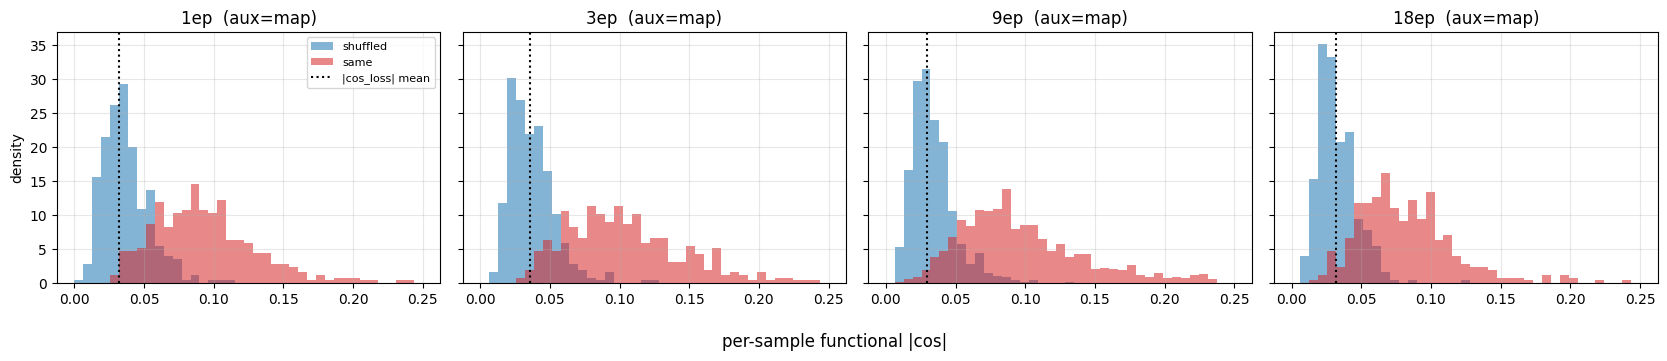

In [5]:
fig, axes = plt.subplots(1, len(CKPTS), figsize=(4.2*len(CKPTS), 3.6), sharex=True, sharey=True)
aux = 'map'
for ax, ck in zip(np.atleast_1d(axes), CKPTS):
    d = df[df.ckpt == ck]
    bins = np.linspace(0, 0.25, 40)
    ax.hist(d[f'cosshuf_absmean_{aux}'].dropna(), bins, alpha=0.55, color=COL['shuf'], label='shuffled', density=True)
    ax.hist(d[f'cosfunc_absmean_{aux}'].dropna(), bins, alpha=0.55, color=COL['same'], label='same', density=True)
    ax.axvline(d[f'cos_loss_{aux}'].abs().mean(), color='k', ls=':', lw=1.5, label='|cos_loss| mean')
    ax.set_title(f'{ck}  (aux={aux})'); ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel('density'); np.atleast_1d(axes)[0].legend(fontsize=8)
fig.supxlabel('per-sample functional |cos|'); plt.tight_layout(); plt.show()

## Fig 4 — paired 차이 (same − shuf) 분포: 거의 전부 양수
같은 scene에서 same > shuf (paired) — 결합이 샘플-특이적이라는 직접 증거.

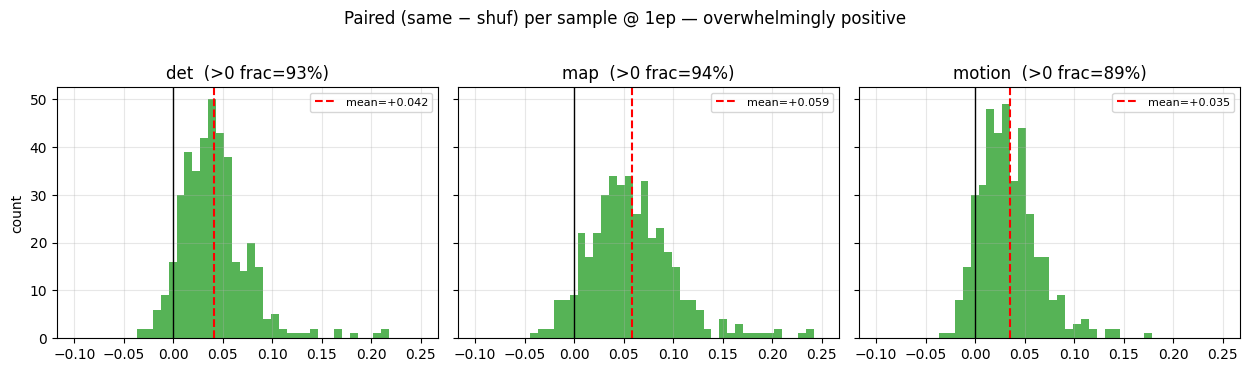

In [6]:
fig, axes = plt.subplots(1, len(AUX), figsize=(4.2*len(AUX), 3.6), sharey=True)
ck = CKPTS[0]
d = df[df.ckpt == ck]
for ax, aux in zip(np.atleast_1d(axes), AUX):
    diff = (d[f'cosfunc_absmean_{aux}'] - d[f'cosshuf_absmean_{aux}']).dropna()
    ax.hist(diff, np.linspace(-0.1, 0.25, 45), color='#2ca02c', alpha=0.8)
    ax.axvline(0, color='k', lw=1); ax.axvline(diff.mean(), color='r', ls='--', lw=1.5, label=f'mean={diff.mean():+.3f}')
    ax.set_title(f'{aux}  (>0 frac={ (diff>0).mean():.0%})'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel('count')
fig.suptitle(f'Paired (same − shuf) per sample @ {ck} — overwhelmingly positive', y=1.02)
plt.tight_layout(); plt.show()

## Fig 5 — 상쇄 예시: loss-gradient cos는 부호가 0 주변 대칭 (그래서 평균이 죽음)
`cos_loss`(부호있는 값) 분포는 0에 대칭 → 평균≈0.  하지만 |값|은 살아있음(결합 실재).

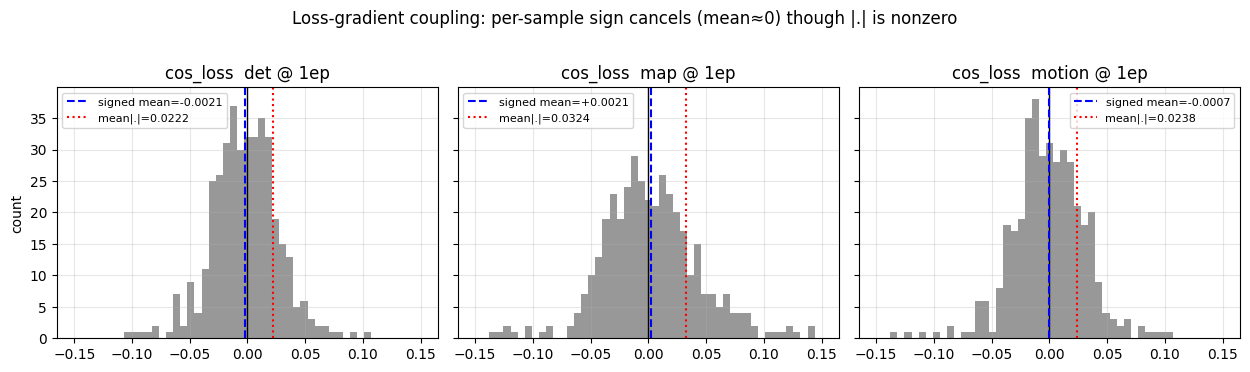

In [7]:
fig, axes = plt.subplots(1, len(AUX), figsize=(4.2*len(AUX), 3.6), sharey=True)
ck = CKPTS[0]; d = df[df.ckpt == ck]
for ax, aux in zip(np.atleast_1d(axes), AUX):
    v = d[f'cos_loss_{aux}'].dropna()
    ax.hist(v, np.linspace(-0.15, 0.15, 50), color=COL['loss'], alpha=0.8)
    ax.axvline(0, color='k', lw=1)
    ax.axvline(v.mean(), color='b', ls='--', lw=1.5, label=f'signed mean={v.mean():+.4f}')
    ax.axvline(v.abs().mean(), color='r', ls=':', lw=1.5, label=f'mean|.|={v.abs().mean():.4f}')
    ax.set_title(f'cos_loss  {aux} @ {ck}'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel('count')
fig.suptitle('Loss-gradient coupling: per-sample sign cancels (mean≈0) though |.| is nonzero', y=1.02)
plt.tight_layout(); plt.show()

## Fig 6 — 체크포인트 추세: same / shuf / |loss| (aux별)
same은 모든 epoch에서 shuf·|loss| 위, 격차 유지(중기 3/9ep 약간 강).

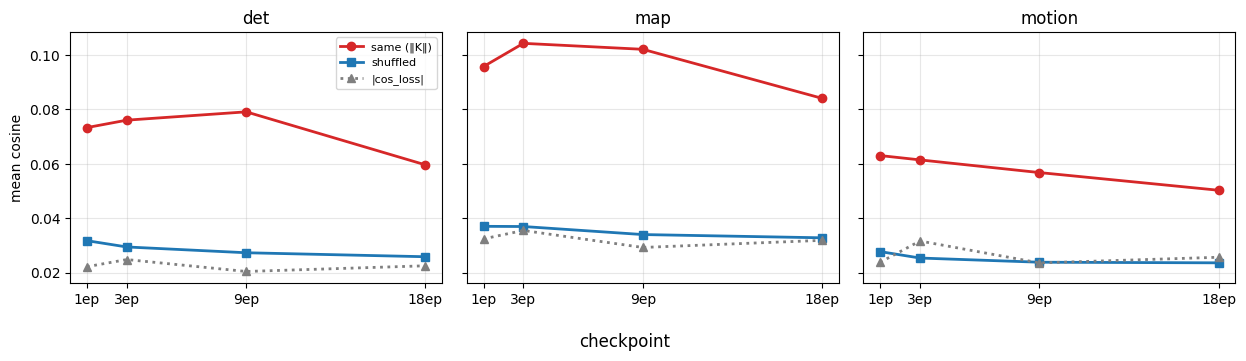

In [8]:
fig, axes = plt.subplots(1, len(AUX), figsize=(4.2*len(AUX), 3.6), sharey=True)
xs = [ORDER[c] for c in CKPTS]
for ax, aux in zip(np.atleast_1d(axes), AUX):
    g = lambda col: [S[(S.ckpt==c)&(S.aux==aux)][col].iloc[0] for c in CKPTS]
    ax.plot(xs, g('same'), 'o-', color=COL['same'], label='same (‖K‖)', lw=2)
    ax.plot(xs, g('shuf'), 's-', color=COL['shuf'], label='shuffled', lw=2)
    ax.plot(xs, g('loss'), '^:', color=COL['loss'], label='|cos_loss|', lw=2)
    ax.set_xticks(xs); ax.set_xticklabels(CKPTS); ax.set_title(aux); ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel('mean cosine'); np.atleast_1d(axes)[0].legend(fontsize=8)
fig.supxlabel('checkpoint'); plt.tight_layout(); plt.show()

## 결론
- **cosfunc_same = shuffled null의 2.1~2.8×, p<0.001** (전 ckpt·task) → cross-task 함수결합은 *scene-특이적*으로 **실재**.
- **|cos_loss| ≈ cosshuf** → loss-gradient는 일반 공유부분공간만 보고, scene-특이적 결합은 *못 봄* (게다가 부호 상쇄).
- ⇒ **"aux↔plan은 함수적으로 결합돼 있으나 loss-gradient엔 안 보인다"** — MTL gradient method가 실재 결합에도 실패하는 이유.
- caveat: 출력 proxy=refine[-1] query, 한 모델(HiP-AD), 결합실재≠method성공.